In [1]:
import pandas as pd

In [ ]:
# merging further df: e.g. brands etc
# setting categories and further analysis of business questions
# visualisation and building representative graphs

# IMPORTING DATA

In [2]:
url1 = "https://drive.google.com/file/d/1fqt7K0MNun8h4sN8CeHYWceUTiI0msOT/view" #
path1= "https://drive.google.com/uc?export=download&id="+url1.split("/")[-2]
df_merged_all = pd.read_csv(path1)

In [3]:
url2 = "https://drive.google.com/file/d/1if_yU1VxvQQHMmZ487Bqe83CABwQ-jQ8/view?usp=drive_open" #
path2= "https://drive.google.com/uc?export=download&id="+url2.split("/")[-2]
df_brands = pd.read_csv(path2)

In [4]:
url3 = "https://drive.google.com/file/d/1BmgjuLVweSxLQYWnkxPB5UDW_ZfLsfQc/view" #
path3= "https://drive.google.com/uc?export=download&id="+url3.split("/")[-2]
df_sales = pd.read_csv(path3)

In [5]:
df_merged_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70373 entries, 0 to 70372
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          70373 non-null  int64  
 1   created_date      70373 non-null  object 
 2   total_paid        70373 non-null  float64
 3   state             70373 non-null  object 
 4   id                70373 non-null  int64  
 5   id_order          70373 non-null  int64  
 6   product_id        70373 non-null  int64  
 7   product_quantity  70373 non-null  int64  
 8   sku               70373 non-null  object 
 9   unit_price        70373 non-null  float64
 10  date              70373 non-null  object 
 11  name              70373 non-null  object 
 12  desc              70373 non-null  object 
 13  price             70373 non-null  float64
 14  in_stock          70373 non-null  int64  
 15  type              70373 non-null  object 
 16  discount_percent  70373 non-null  float6

In [6]:
total_merged = df_merged_all.drop(["id", "id_order", "product_id"], axis=1)

In [7]:
total_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70373 entries, 0 to 70372
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          70373 non-null  int64  
 1   created_date      70373 non-null  object 
 2   total_paid        70373 non-null  float64
 3   state             70373 non-null  object 
 4   product_quantity  70373 non-null  int64  
 5   sku               70373 non-null  object 
 6   unit_price        70373 non-null  float64
 7   date              70373 non-null  object 
 8   name              70373 non-null  object 
 9   desc              70373 non-null  object 
 10  price             70373 non-null  float64
 11  in_stock          70373 non-null  int64  
 12  type              70373 non-null  object 
 13  discount_percent  70373 non-null  float64
dtypes: float64(4), int64(3), object(7)
memory usage: 7.5+ MB


In [8]:
df_brands

,short,long
0,8MO,8Mobility
1,ACM,Acme
2,ADN,Adonit
3,AII,Aiino
4,AKI,Akitio
...,...,...
182,XOO,Xoopar
183,XRI,X-Rite
184,XTO,Xtorm
185,ZAG,ZaggKeys


In [9]:
df_merged_all.isna().sum()

,0
order_id,0
created_date,0
total_paid,0
state,0
id,0
id_order,0
product_id,0
product_quantity,0
sku,0
unit_price,0


In [10]:
df_merged_all.duplicated().sum()

np.int64(9633)

In [11]:
df_merged_all_enriched = df_merged_all.drop_duplicates()

#JOIN BRANDS, SALES AND REST IN ONE df

In [12]:


# 1. Select ONLY the ID columns and the NEW columns from the second file
# This prevents the "name_x/name_y" mess!
cols_to_add = ['order_id', 'sku', 'short', 'long', 'revenue', 'price_difference']

# 2. Perform the merge using both 'order_id' and 'sku' as the key
# We use 'how="left"' to make sure we don't lose any sales data
df_merged_all_enriched = pd.merge(
    df_merged_all_enriched,
    df_sales[cols_to_add],
    on=['order_id', 'sku'],
    how='left'
)

# 3. Double check for any duplicates created by the merge
df_merged_all_enriched = df_merged_all_enriched.drop_duplicates()

# 4. Show the clean list of columns
print("--- YOUR NEW CLEAN COLUMNS ---")
print(df_merged_all_enriched.columns.tolist())

--- YOUR NEW CLEAN COLUMNS ---
['order_id', 'created_date', 'total_paid', 'state', 'id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price', 'date', 'name', 'desc', 'price', 'in_stock', 'type', 'discount_percent', 'short', 'long', 'revenue', 'price_difference']


In [13]:
df_merged_all_enriched

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,...,name,desc,price,in_stock,type,discount_percent,short,long,revenue,price_difference
0,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,0,1,LAC0212,129.16,...,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1,11935397,7.736267,LAC,LaCie,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,0,1,PAR0074,10.77,...,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,0,11905404,40.133407,PAR,Parrot,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,0,1,OWC0074,77.99,...,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1,1364,22.002200,OWC,OWC,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,0,1,TAD0007,149.00,...,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,0,11905404,16.759777,TAD,Tado,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,0,2,PAC1561,52.99,...,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,1,11935397,49.023569,PAC,Pack,105.98,6.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60741,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,0,1,APP0927,13.99,...,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1,5384,60.028571,APP,Apple,13.99,4.99
60742,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,0,2,APP0698,9.99,...,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,60.040000,APP,Apple,19.98,4.99
60743,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,0,2,APP0698,9.99,...,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,60.040000,APP,Apple,19.98,4.99
60744,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,0,3,APP0698,9.99,...,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,60.040000,APP,Apple,29.97,4.99


#CLEANING STEP

In [14]:
df_merged_all_enriched.isna().sum()

,0
order_id,0
created_date,0
total_paid,0
state,0
id,0
id_order,0
product_id,0
product_quantity,0
sku,0
unit_price,0


In [15]:
df_merged_all_enriched = df_merged_all_enriched.dropna(subset=['short','long', 'revenue', 'price_difference'])

In [16]:
df_merged_all_enriched.isna().sum()

,0
order_id,0
created_date,0
total_paid,0
state,0
id,0
id_order,0
product_id,0
product_quantity,0
sku,0
unit_price,0


In [17]:
df_merged_all_enriched.duplicated().sum()

np.int64(0)

In [18]:
df_cleaned_all = df_merged_all_enriched.drop_duplicates()

In [19]:
print(df_cleaned_all.duplicated().sum())

0


In [20]:
df_cleaned_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56381 entries, 0 to 60745
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56381 non-null  int64  
 1   created_date      56381 non-null  object 
 2   total_paid        56381 non-null  float64
 3   state             56381 non-null  object 
 4   id                56381 non-null  int64  
 5   id_order          56381 non-null  int64  
 6   product_id        56381 non-null  int64  
 7   product_quantity  56381 non-null  int64  
 8   sku               56381 non-null  object 
 9   unit_price        56381 non-null  float64
 10  date              56381 non-null  object 
 11  name              56381 non-null  object 
 12  desc              56381 non-null  object 
 13  price             56381 non-null  float64
 14  in_stock          56381 non-null  int64  
 15  type              56381 non-null  object 
 16  discount_percent  56381 non-null  float64
 17

In [21]:
print(f"Rows before: {len(df_merged_all_enriched)}")
print(f"Rows after: {len(df_cleaned_all)}")
print(f"Rows removed: {len(df_merged_all_enriched) - len(df_cleaned_all)}")

Rows before: 56381
Rows after: 56381
Rows removed: 0


#ASSIGN TYPE

BY REVENUE

In [22]:
# 1. Filter for Completed
# 2. Group by type
# 3. Select the 'total_price' column to sum
# 4. Sort from High to Low
#"Which product types have the most revenue listed in df?"
top_revenue_types = df_cleaned_all.loc[df_cleaned_all['state'] == 'Completed'] \
                    .groupby('type')['revenue'].sum() \
                    .sort_values(ascending=False).head(10)

print(top_revenue_types)

type
5,74E+15    1571736.24
1,02E+12    1075774.05
11935397     823906.35
1296         749498.17
1282         565200.57
12215397     464955.01
12175397     421487.77
1405         416814.86
1364         404849.29
12655397     361919.84
Name: revenue, dtype: float64


In [23]:
top_revenue_with_orig_index = (
    df_cleaned_all[df_cleaned_all['state'] == 'Completed']
    .reset_index() # This moves the original 0, 1, 2... into a column called 'index'
    .groupby('type')
    .agg({
        'index': 'first',         # Keeps the VERY FIRST row number where this type appeared
        'revenue': 'sum'
    })
    .sort_values(by='revenue', ascending=False)
    .head(10)
)

print(top_revenue_with_orig_index)

          index     revenue
type                       
5,74E+15     50  1571736.24
1,02E+12    129  1075774.05
11935397      0   823906.35
1296         23   749498.17
1282        180   565200.57
12215397      9   464955.01
12175397     56   421487.77
1405         65   416814.86
1364          2   404849.29
12655397     11   361919.84


BY SKU

In [24]:
top_10_types_by_sku = df_cleaned_all.groupby("type")["sku"].count().sort_values(ascending=False).head(10)
#"Which product types have the most items listed in our catalog?"

print(top_10_types_by_sku)

type
11865403    4325
11935397    3930
1364        3267
11905404    3133
5384        2347
12215397    2037
12585395    1997
12655397    1765
1296        1583
1230        1340
Name: sku, dtype: int64


In [25]:
top_sku_with_orig_index = (
    df_cleaned_all
    .reset_index()               # Moves the original row numbers (0, 1, 2...) into a column
    .groupby('type')
    .agg({
        'index': 'first',        # Shows the first row number where this type appeared
        'sku': 'count'           # Counts how many times this type appears
    })
    .sort_values(by='sku', ascending=False) # Sorts by the highest count
    .head(10)
)

print(top_sku_with_orig_index)

          index   sku
type                 
11865403     12  4325
11935397      0  3930
1364          2  3267
11905404      1  3133
5384         18  2347
12215397      9  2037
12585395     37  1997
12655397     11  1765
1296         23  1583
1230         19  1340


COMMON TYPES IDENTIFIED

In [26]:
# 1. Get the list of Type IDs from both results
top_sku_list = top_sku_with_orig_index.index.tolist()
top_revenue_list = top_revenue_with_orig_index.index.tolist()

# 2. Find the intersection (the ones in both)
common_types = set(top_sku_list).intersection(top_revenue_list)

print("Types that are in both Top 10 lists:")
print(common_types)

Types that are in both Top 10 lists:
{'11935397', '1364', '12215397', '12655397', '1296'}


#PRIORITY TYPES FOR SETTING GROUPS

In [27]:
# 1. Get the Top 5 IDs from the Revenue table
top_5_revenue_ids = top_revenue_with_orig_index.head(5).index.tolist()

# 2. Get all IDs that appear in BOTH Top 10 lists (Intersection)
top_sku_ids = top_sku_with_orig_index.index.tolist()
top_revenue_ids = top_revenue_with_orig_index.index.tolist()
common_ids = list(set(top_sku_ids).intersection(top_revenue_ids))

# 3. Combine them and remove duplicates (using set() again)
# This gives you a single list of your most important "Power Types"
priority_type_ids = list(set(top_5_revenue_ids + common_ids))

# 4. Create a final summary table for just these types
priority_summary = (
    df_cleaned_all[df_cleaned_all['type'].isin(priority_type_ids)]
    .groupby('type')
    .agg({
        'sku': 'count',
        'revenue': 'sum',
        'price': 'mean' # Adding average catalog price to see how expensive they are
    })
    .sort_values(by='revenue', ascending=False)
)

print("--- Priority Types for Discount Analysis ---")
print(priority_summary)

--- Priority Types for Discount Analysis ---
           sku     revenue        price
type                                   
5,74E+15   561  1571736.24  3172.120374
1,02E+12   464  1075774.05  2486.812435
11935397  3930   823906.35   232.340468
1296      1583   749498.17   477.887397
1282       409   565200.57  1612.363007
12215397  2037   464955.01   239.988479
1364      3267   404849.29   145.485002
12655397  1765   361919.84   166.202916


EXTRA

In [28]:
top_products_types = df_cleaned_all.groupby('type')['price'].sum() \
                    .sort_values(ascending=False).head(10)
top_products_types

,price
type,
"5,74E+15",1779559.530
"1,02E+12",1153880.970
11935397,913098.040
1296,756495.749
1282,659456.470
1405,490661.930
12215397,488856.532
1364,475299.500
12175397,455812.430


In [29]:
# Grouping by type and calculating both at once
type_analysis = df_cleaned_all.groupby('type').agg({
    'price': 'sum',      # Total Catalog Value
    'revenue': 'sum', # Total Actual Revenue
    'sku': 'count'       # Number of sales
}).reset_index()

# Calculate the "Revenue Gap" (Total discounts given)
type_analysis['discount_percent'] = type_analysis['price'] - type_analysis['revenue']

# Sort by Revenue to see the real winners
type_analysis = type_analysis.sort_values(by='revenue', ascending=False)

print(type_analysis.head(10))

        type        price     revenue   sku  discount_percent
95  5,74E+15  1779559.530  1571736.24   561        207823.290
0   1,02E+12  1153880.970  1075774.05   464         78106.920
18  11935397   913098.040   823906.35  3930         89191.690
40      1296   756495.749   749498.17  1583          6997.579
39      1282   659456.470   565200.57   409         94255.900
25  12215397   488856.532   464955.01  2037         23901.522
24  12175397   455812.430   421487.77   904         34324.660
58      1405   490661.930   416814.86  1296         73847.070
49      1364   475299.500   404849.29  3267         70450.210
35  12655397   293348.146   361919.84  1765        -68571.694


#SETTING CATEGORY BY KEY WORDS

In [30]:

# 1. Filter for your top types only
priority_df = df_cleaned_all[df_cleaned_all['type'].isin(priority_type_ids)]

# 2. Get all words, make them lowercase, and count them
# We split by spaces and "stack" them into one long list
word_counts = (
    priority_df['name']
    .str.lower()                 # Handles the iPhone vs iphone issue
    .str.replace(r'[^a-zA-Z0-9\s]', '', regex=True) # Removes punctuation like ( ) or -
    .str.split(expand=True)
    .stack()
    .value_counts()
)

# 3. See the top 30 most frequent words
print("--- Top Keywords in your Priority Types ---")
print(word_counts.head(30))

--- Top Keywords in your Priority Types ---
mac        4993
drive      4202
hard       4116
usb        3348
memory     3262
30         3162
ssd        2912
sodimm     2862
ddr3       2481
owc        2210
and        2141
8gb        2009
lacie      1980
disk       1871
crucial    1770
pro        1645
1tb        1537
apple      1503
16gb       1491
wd         1483
monitor    1475
35         1437
pc         1409
2tb        1392
core       1312
usbc       1217
4tb        1209
macbook    1182
25         1164
27         1160
Name: count, dtype: int64


SETTING KEYWORDS INTO CATEGORIES

In [31]:
#import pandas as pd

# 1. Define the Logic with the "Accessories Filter" at the top
def get_category(name):
    # Convert to string and lowercase once at the start
    name = str(name).lower()

    # --- PRIORITY 1: Accessories & Connectivity ---
    # We check these first so "iPhone Case" doesn't get labeled as "Smartphone"
    if any(x in name for x in ['case', 'cover', 'adapter', 'cable', 'battery','hdmi', 'monitor', 'keyboard', 'mouse']):
        return 'Accessories'

    # --- PRIORITY 2: High Value Devices ---
    if any(x in name for x in ['iphone', 'samsung', 'huawei', 'phone', 'mobile']):
        return 'Smartphone'

    if any(x in name for x in ['macbook', 'mac ', 'imac', 'pro', 'retina', 'laptop']):
        return 'Computer'

    if any(x in name for x in ['ipad', 'tablet', 'galaxy tab', 'AirPods']):
        return 'Tablet, Earphone'

    # --- PRIORITY 3: Components & Upgrades ---
    if any(x in name for x in ['ssd', 'drive', 'hard', 'disk', '1tb', '2tb', '500gb', 'owc', 'lacie']):
        return 'Storage'

    if any(x in name for x in ['memory', 'ram', 'sodimm', 'ddr3', 'ddr4', '8gb', '16gb', 'crucial']):
        return 'Memory/RAM'

    return 'Other'

# 2. Apply to your 'name' column
df_cleaned_all['category'] = df_cleaned_all['name'].apply(get_category)

# 3. Quick check of the top results
print(df_cleaned_all['category'].value_counts())

category
Accessories         18353
Computer            13009
Other                9056
Smartphone           9002
Storage              5783
Tablet, Earphone      900
Memory/RAM            278
Name: count, dtype: int64


In [32]:
df_cleaned_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56381 entries, 0 to 60745
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56381 non-null  int64  
 1   created_date      56381 non-null  object 
 2   total_paid        56381 non-null  float64
 3   state             56381 non-null  object 
 4   id                56381 non-null  int64  
 5   id_order          56381 non-null  int64  
 6   product_id        56381 non-null  int64  
 7   product_quantity  56381 non-null  int64  
 8   sku               56381 non-null  object 
 9   unit_price        56381 non-null  float64
 10  date              56381 non-null  object 
 11  name              56381 non-null  object 
 12  desc              56381 non-null  object 
 13  price             56381 non-null  float64
 14  in_stock          56381 non-null  int64  
 15  type              56381 non-null  object 
 16  discount_percent  56381 non-null  float64
 17

#SETTING KEYWORD BY DESC - using this column gives more precise details

In [33]:
import pandas as pd

# 1. Define the Logic with the "Accessories Filter" at the top
def get_category_from_desc(description):
    # Convert to string and lowercase once at the start to match all cases
    text = str(description).lower()

    # --- PRIORITY 1: Accessories & Connectivity ---
    # We check these first so "iPhone Case" doesn't get labeled as "Smartphone"
    if any(x in text for x in ['case', 'cover', 'adapter', 'cable', 'battery', 'hdmi', 'monitor', 'keyboard', 'mouse']):
        return 'Accessories'

    # --- PRIORITY 2: High Value Devices ---
    if any(x in text for x in ['iphone', 'samsung', 'huawei', 'phone', 'mobile']):
        return 'Smartphone'

    if any(x in text for x in ['macbook', 'mac ', 'imac', 'pro', 'retina', 'laptop']):
        return 'Computer'

    # Changed 'AirPods' to 'airpods' to match lowercase text
    if any(x in text for x in ['ipad', 'tablet', 'galaxy tab', 'airpods']):
        return 'Tablet, Earphone'

    # --- PRIORITY 3: Components & Upgrades ---
    if any(x in text for x in ['ssd', 'drive', 'hard', 'disk', '1tb', '2tb', '500gb', 'owc', 'lacie']):
        return 'Storage'

    if any(x in text for x in ['memory', 'ram', 'sodimm', 'ddr3', 'ddr4', '8gb', '16gb', 'crucial']):
        return 'Memory/RAM'

    return 'Other'

# 2. Apply to your 'desc' column
# .fillna('') ensures that if a description is missing, the code doesn't crash
df_cleaned_all['category'] = df_cleaned_all['desc'].fillna('').apply(get_category_from_desc)

# 3. Quick check of the top results
print("--- Final Category Counts (Source: Description Column) ---")
print(df_cleaned_all['category'].value_counts())

--- Final Category Counts (Source: Description Column) ---
category
Computer            19808
Accessories         17327
Smartphone          11471
Other                4621
Storage              1443
Tablet, Earphone     1174
Memory/RAM            537
Name: count, dtype: int64


In [34]:
# Compare the first 20 rows of both columns
print(df_cleaned_all[['name', 'category']].head(30))

                                                 name          category
0   LaCie Porsche Design Desktop Drive 4TB USB 3.0...          Computer
1                Parrot 550mAh battery for MiniDrones       Accessories
2             Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM          Computer
3           Tado Smart Climate Control Intelligent AC             Other
4   Macally External Hard Drive 1TB 35 "USB 3.0 SA...          Computer
5   iFixit battery Macbook Pro 13 "OEM (Mid 2009 /...       Accessories
6   Tucano Nido Hard-Shell Case MacBook Pro 13 "(L...       Accessories
7                     iFixit P5 Pentalobe Screwdriver          Computer
8   Mophie Juice Pack 1560mAh + Wireless Charging ...       Accessories
9                        Crucial MX300 525GB SSD Disk          Computer
10  OWC SSD installation Kit for iMac 27 "(2010) w...          Computer
11  Seagate Barracuda 3TB 35 "SATA hard drive Mac ...          Computer
12   Case Apple iPhone 6 / 6S Leather Case Blue Night       Acce

In [35]:
df_cleaned_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56381 entries, 0 to 60745
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56381 non-null  int64  
 1   created_date      56381 non-null  object 
 2   total_paid        56381 non-null  float64
 3   state             56381 non-null  object 
 4   id                56381 non-null  int64  
 5   id_order          56381 non-null  int64  
 6   product_id        56381 non-null  int64  
 7   product_quantity  56381 non-null  int64  
 8   sku               56381 non-null  object 
 9   unit_price        56381 non-null  float64
 10  date              56381 non-null  object 
 11  name              56381 non-null  object 
 12  desc              56381 non-null  object 
 13  price             56381 non-null  float64
 14  in_stock          56381 non-null  int64  
 15  type              56381 non-null  object 
 16  discount_percent  56381 non-null  float64
 17

SAVING NEW CSV

In [36]:
#df_cleaned_all.to_csv('cleaned_data_with_categories.csv', index=False)

In [37]:
#df_cleaned_all.to_csv('cl_sales_type_data.csv', index=False)

#print("File saved successfully!")

#ANSWERING QUESTIONs

1. DATA PERIOD

In [38]:
print(f"Data Starts: {df_cleaned_all['created_date'].min()}")
print(f"Data Ends: {df_cleaned_all['created_date'].max()}")
#What is the time period that the dataset covers?

Data Starts: 2017-01-01 01:51:47
Data Ends: 2018-03-14 12:03:52


2. REVENUE TOTAL

In [39]:

# 1. Calculate Total Revenue across the whole company
total_revenue = df_cleaned_all['revenue'].sum()

# 2. Filter for Apple and sum their specific revenue
# .isin() checks if the value in 'short' is either 'APP' or 'AP2'
apple_revenue = df_cleaned_all[df_cleaned_all['short'].isin(['APP', 'AP2'])]['revenue'].sum()

# 3. Calculate the Percentage Share
apple_share = (apple_revenue / total_revenue) * 100

# Print results for your slide
print(f"Total Company Revenue: ${total_revenue:,.2f}")
print(f"Total Apple Revenue:   ${apple_revenue:,.2f}")
print(f"Apple Revenue Share:    {apple_share:.1f}%")

Total Company Revenue: $12,589,021.13
Total Apple Revenue:   $5,710,622.76
Apple Revenue Share:    45.4%


3. DISCOUNT %

In [40]:
df_cleaned_all['discount_percent'].mean()

np.float64(21.45075598774574)

4. AVG/MIN/MAX

In [41]:
df_cleaned_all.describe()

,order_id,total_paid,id,id_order,product_id,product_quantity,unit_price,price,in_stock,discount_percent,revenue,price_difference
count,56381.000000,56381.000000,5.638100e+04,56381.000000,56381.0,56381.000000,56381.000000,56381.000000,56381.000000,56381.000000,56381.000000,56381.000000
mean,416200.927493,345.875911,1.389786e+06,416200.927493,0.0,1.118036,211.547477,250.532948,0.567425,21.450756,223.284815,5.598278
std,64991.249744,634.146567,1.495765e+05,64991.249744,0.0,0.759304,451.275743,510.323080,0.495437,18.728433,471.872881,17.447696
min,241423.000000,2.820000,1.119116e+06,241423.000000,0.0,1.000000,1.000000,2.990000,0.000000,-212.265332,1.990000,0.000000
25%,368199.000000,55.390000,1.275073e+06,368199.000000,0.0,1.000000,28.990000,39.950000,0.000000,8.640288,29.990000,0.000000
50%,419531.000000,126.900000,1.393519e+06,419531.000000,0.0,1.000000,69.990000,89.950000,1.000000,17.431992,71.980000,4.990000
75%,470935.000000,346.480000,1.515639e+06,470935.000000,0.0,1.000000,172.990000,209.990000,1.000000,28.575511,186.800000,6.990000
max,527112.000000,13387.780000,1.649593e+06,527112.000000,0.0,72.000000,8287.800000,9799.000000,1.000000,97.712652,13387.770000,484.990000


5. TOP 10 UNITS SOLD

In [42]:
# Top 10 products by number of units sold
top_sold_volume = df_cleaned_all['name'].value_counts().head(10)
print(top_sold_volume)

name
IPhone AppleCare Protection Plan                                        863
AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch    537
Apple Lightning Cable Connector to USB 1m White (OEM)                   468
EarPods Apple Headphones with Remote and Mic (OEM)                      367
Samsung 850 EVO SSD Disk 500GB                                          302
Crucial MX300 525GB SSD Disk                                            279
Red 4TB WD 35 "Mac PC hard drive and NAS                                266
Apple iPhone 6 32GB Space Gray                                          254
Apple Magic Mouse 2                                                     240
Apple iPhone 32GB Space Gray                                            224
Name: count, dtype: int64


6. NUMBER OF PRODUCTS IN CATEGORIES

In [43]:
# Show how many products fell into each of your new categories
classification_summary = df_cleaned_all['category'].value_counts().reset_index()
classification_summary.columns = ['Category', 'Number of Products']

print("--- Classification Results ---")
print(classification_summary)

# Pro Tip: Calculate what % of the total catalog each category represents
classification_summary['Percentage'] = (classification_summary['Number of Products'] / len(df_cleaned_all)) * 100
print(classification_summary)

--- Classification Results ---
           Category  Number of Products
0          Computer               19808
1       Accessories               17327
2        Smartphone               11471
3             Other                4621
4           Storage                1443
5  Tablet, Earphone                1174
6        Memory/RAM                 537
           Category  Number of Products  Percentage
0          Computer               19808   35.132403
1       Accessories               17327   30.731984
2        Smartphone               11471   20.345506
3             Other                4621    8.196023
4           Storage                1443    2.559373
5  Tablet, Earphone                1174    2.082262
6        Memory/RAM                 537    0.952449


#VISUALIZATION

1. TOTAL SALES PERIOD

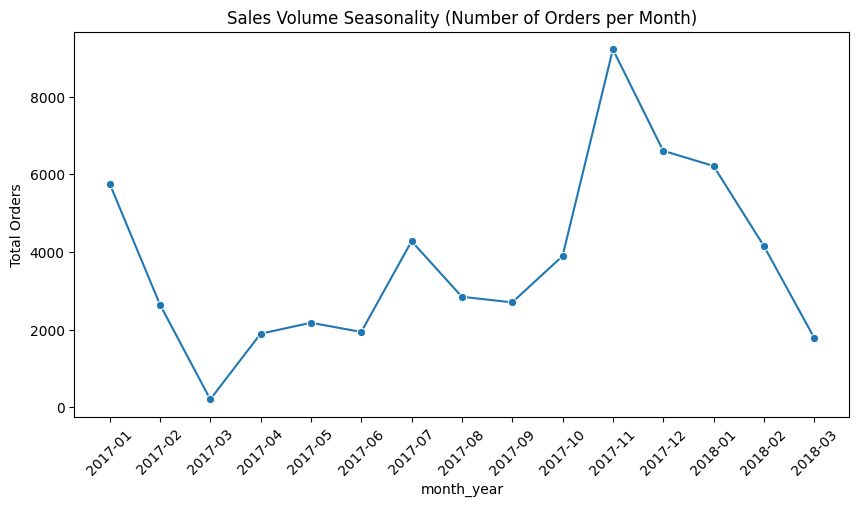

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

df_cleaned_all['created_date'] = pd.to_datetime(df_cleaned_all['created_date'])

# Create a Year-Month column
df_cleaned_all['month_year'] = df_cleaned_all['created_date'].dt.to_period('M').astype(str)

# Count orders per month
monthly_volume = df_cleaned_all.groupby('month_year').size().reset_index(name='order_count')

# Plotting the Volume Seasonality
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_volume, x='month_year', y='order_count', marker='o')
plt.title('Sales Volume Seasonality (Number of Orders per Month)')
plt.xticks(rotation=45)
plt.ylabel('Total Orders')
plt.show()

NOTE: 4621 items not identified

In [45]:
# Use this number to prove why data collection needs to improve
other_count = len(df_cleaned_all[df_cleaned_all['category'] == 'Other'])
print(f"Number of products we couldn't classify (labeled 'Other'): {other_count}")

Number of products we couldn't classify (labeled 'Other'): 4621


BONUS GRAPH -  correlation of unit price vs price: Drawing the "Full Price" Identity Line

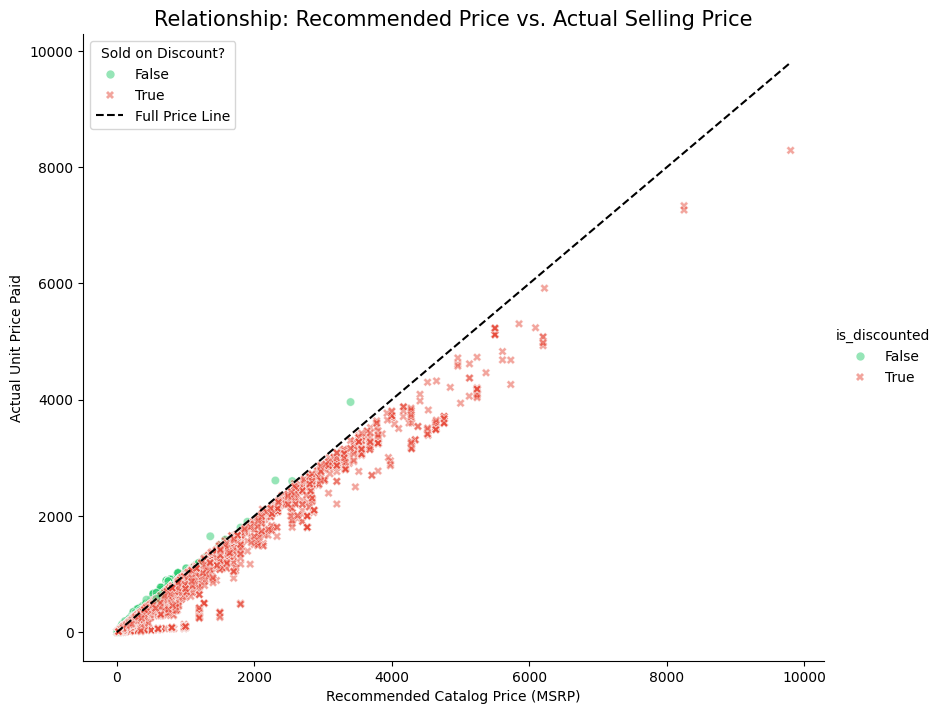

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the 'is_discounted' column if you haven't yet
# This allows us to color-code the dots
df_cleaned_all['is_discounted'] = df_cleaned_all['price'] > df_cleaned_all['unit_price']

# 2. Create the Relational Plot
g = sns.relplot(
    data=df_cleaned_all,
    x="price",
    y="unit_price",
    hue="is_discounted",    # Color by discount status
    style="is_discounted",  # Change shape for better visibility
    palette={True: "#e74c3c", False: "#2ecc71"}, # Red for discount, Green for full price
    alpha=0.5,              # Transparency helps see "overlapping" dots
    height=7,               # Make the plot large enough to read
    aspect=1.2
)

# 3. The Bonus: Drawing the "Full Price" Identity Line
# We get the current axis from the FacetGrid 'g'
ax = g.ax

# Create a line from (0,0) to the max price (e.g., 5000)
line_coords = [0, df_cleaned_all['price'].max()]
ax.plot(line_coords, line_coords, color='black', linestyle='--', label='Full Price Line')

# 4. Final Formatting
plt.title("Relationship: Recommended Price vs. Actual Selling Price", fontsize=15)
plt.xlabel("Recommended Catalog Price (MSRP)")
plt.ylabel("Actual Unit Price Paid")
plt.legend(title="Sold on Discount?")
plt.show()

SCATTER PLOT: price vs unit_price by category

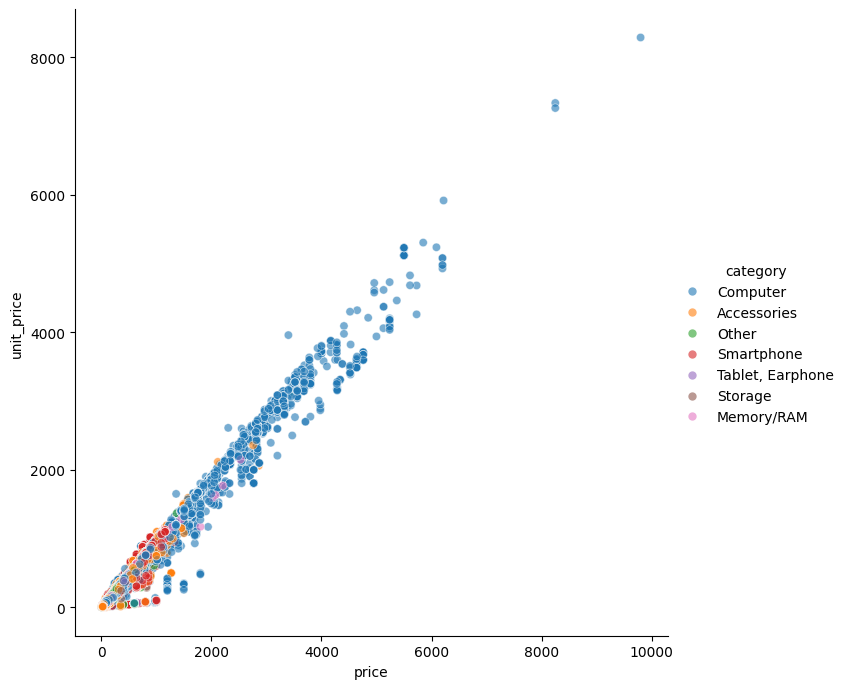

In [47]:
# Change hue to 'category' to see which types of products get the biggest discounts
sns.relplot(
    data=df_cleaned_all,
    x="price",
    y="unit_price",
    hue="category",
    alpha=0.6,
    height=7
)

PRICE ANALYSIS BY BRAND price vs unit price

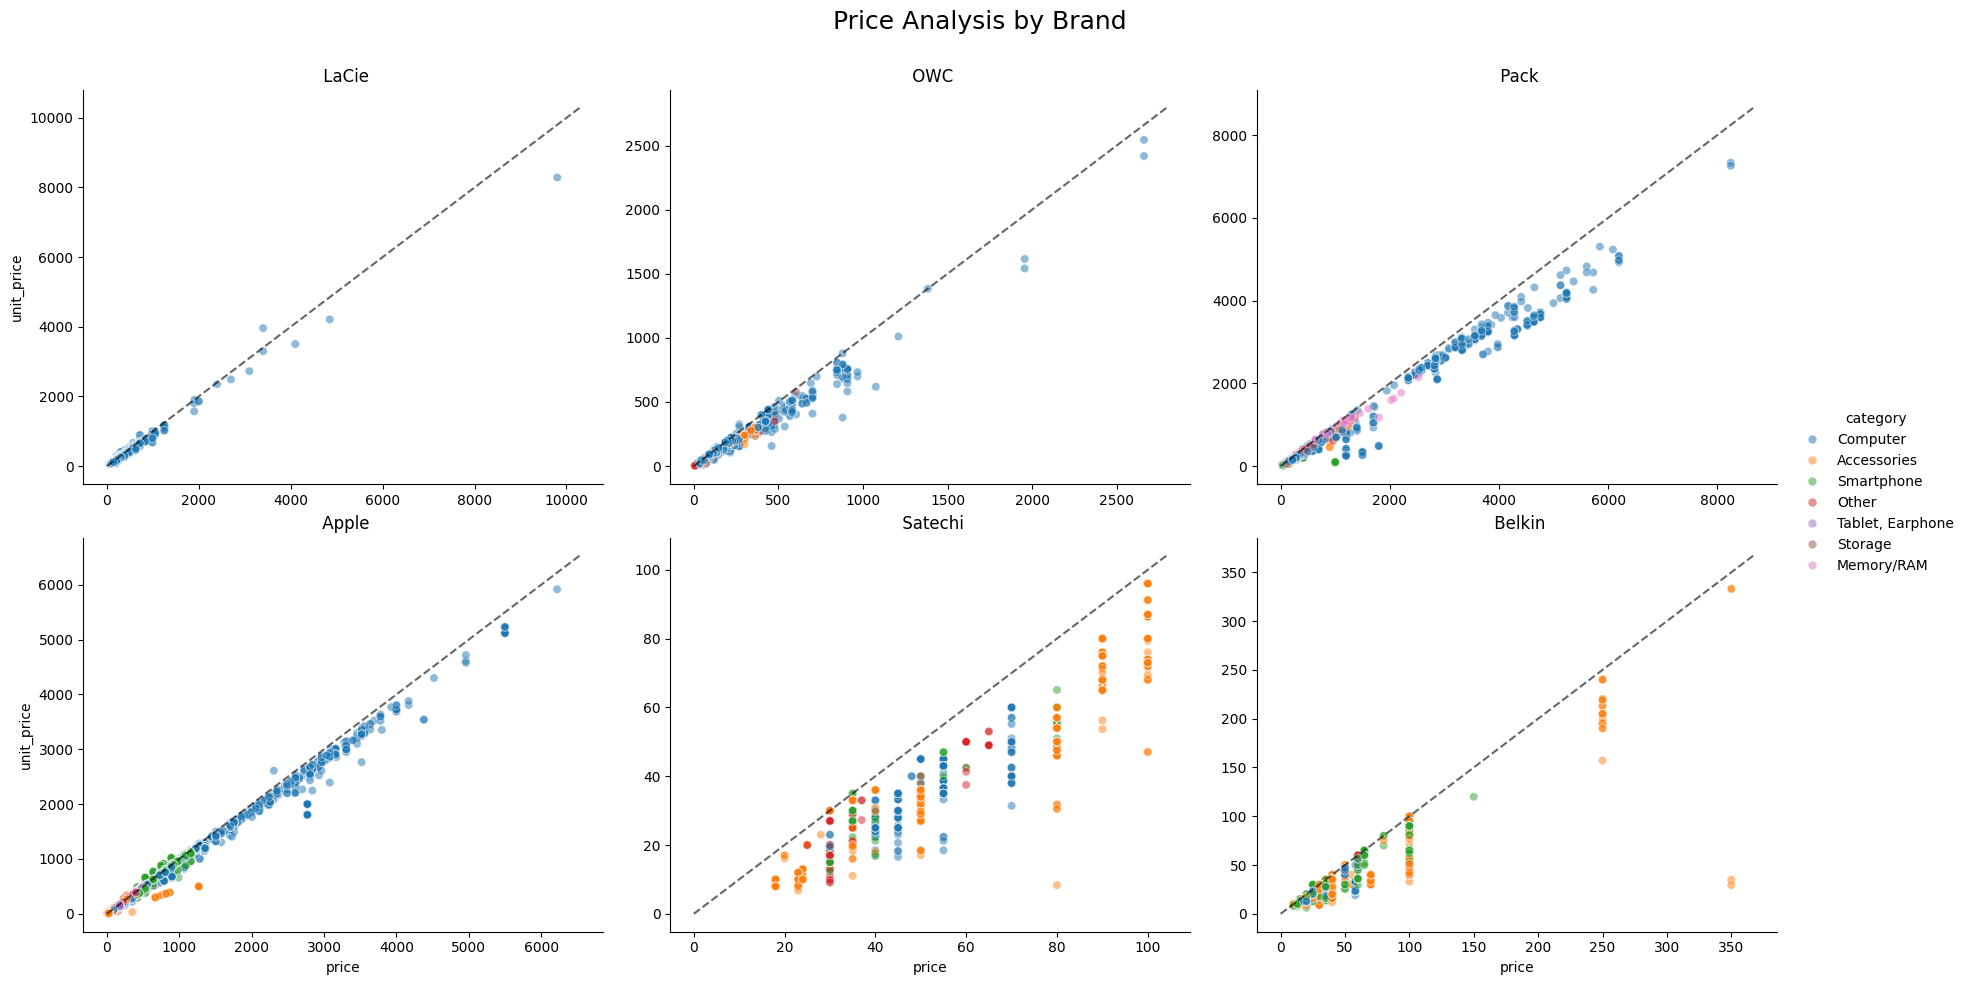

In [48]:
top_brands = df_cleaned_all['short'].value_counts().nlargest(6).index
df_top_brands = df_cleaned_all[df_cleaned_all['short'].isin(top_brands)]

# 2. The Plot - Using 'long' for the columns
g = sns.relplot(
    data=df_top_brands,
    x="price",
    y="unit_price",
    hue="category",    # Still color-coded by your category focus
    col="long",      # Using the Long Name here
    col_wrap=3,        # 3 charts per row
    alpha=0.5,
    height=5,
    aspect=1.2,
    facet_kws={'sharex': False, 'sharey': False} # Allows each brand to scale its own axes
)

# 3. Clean up the titles and add the Identity Line
for ax in g.axes.flat:
    # This draws the "Full Price" line
    # It takes the max x-limit of the current chart to draw the line correctly
    curr_max = ax.get_xlim()[1]
    ax.plot([0, curr_max], [0, curr_max], color='black', linestyle='--', alpha=0.6)

    # This cleans the title (removes "long_x = ")
    title = ax.get_title().split('=')[-1]
    # If the name is too long, we wrap it or truncate it so it fits the screen
    ax.set_title(title[:30] + '...' if len(title) > 30 else title, fontsize=12)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Price Analysis by Brand", fontsize=18)
plt.show()

PRICE RANGE BY CATEGORY

/tmp/ipykernel_14148/3286426353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


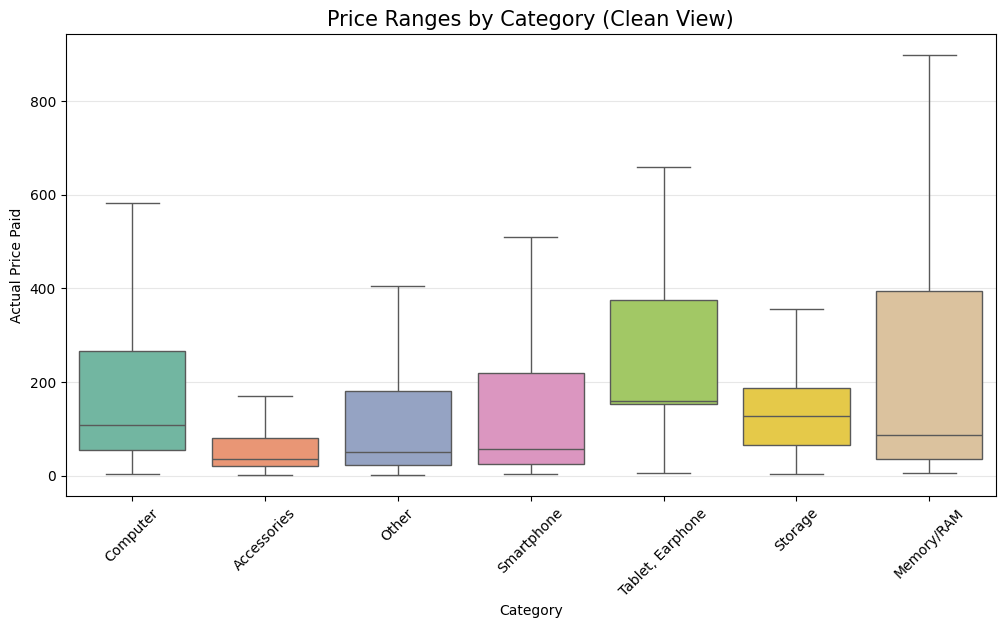

In [49]:
plt.figure(figsize=(12, 6))

# We plot 'category' on the X axis and 'unit_price' on the Y
sns.boxplot(
    data=df_cleaned_all,
    x='category',
    y='unit_price',
    palette='Set2',
    showfliers=False # This hides the "extreme" outlier dots to keep it clean
)

plt.title('Price Ranges by Category (Clean View)', fontsize=15)
plt.ylabel('Actual Price Paid')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

PRODUCTS COUNT VS CATEGORY

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Setup columns
df_cleaned_all['created_date'] = pd.to_datetime(df_cleaned_all['created_date'])
df_cleaned_all['month_year'] = df_cleaned_all['created_date'].dt.to_period('M').astype(str)
df_cleaned_all['is_discounted'] = df_cleaned_all['price'] > df_cleaned_all['unit_price']
sns.set_theme(style="whitegrid")

/tmp/ipykernel_14148/1383301015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned_all, x='category', palette='viridis')


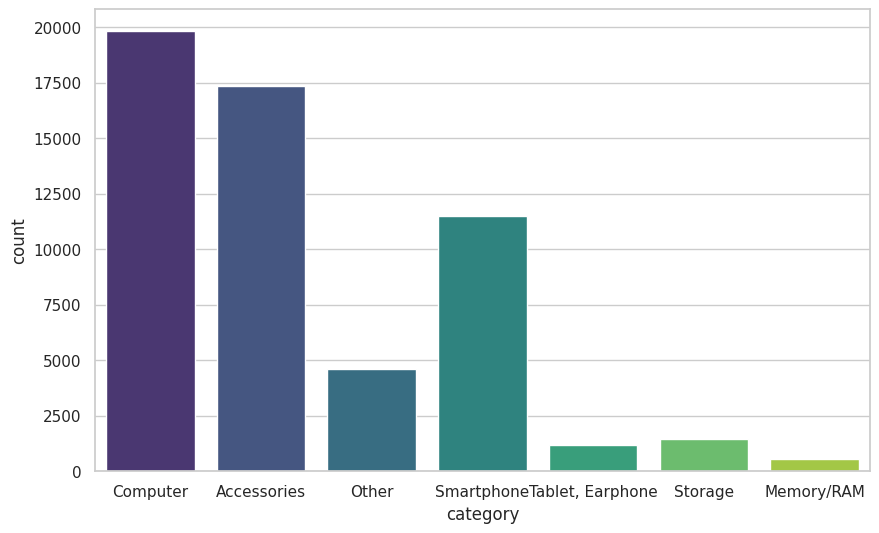

In [51]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned_all, x='category', palette='viridis')
plt.show()

SUMMARY REVENUE BY CATEGORY

/tmp/ipykernel_14148/969666217.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary, x='category', y='revenue', palette='Blues_r')


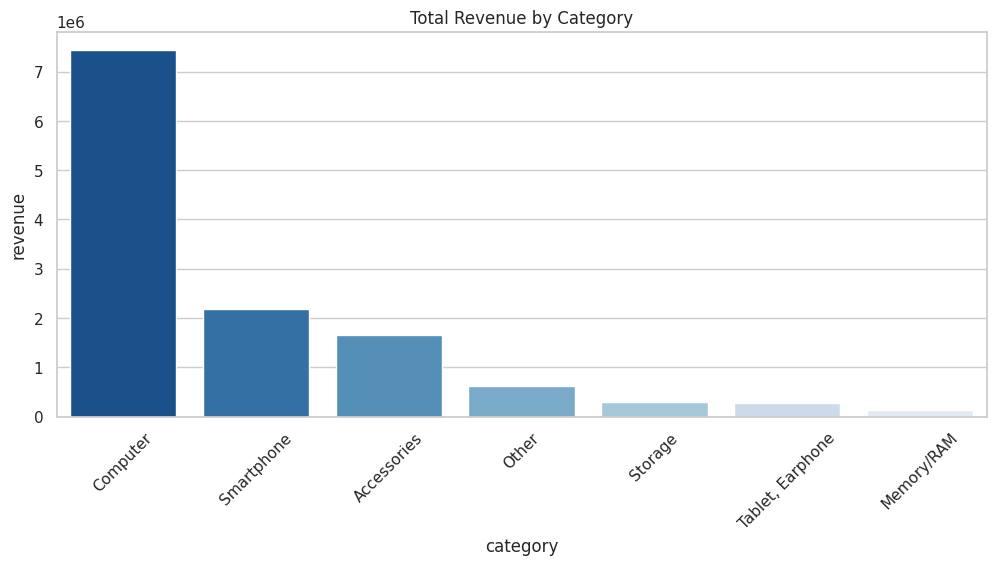

In [52]:
cat_summary = df_cleaned_all.groupby('category').agg({
    'revenue': 'sum',
    'product_quantity': 'sum'
}).sort_values('revenue', ascending=False).reset_index()

# Plot Revenue
plt.figure(figsize=(12, 5))
sns.barplot(data=cat_summary, x='category', y='revenue', palette='Blues_r')
plt.title('Total Revenue by Category')
plt.xticks(rotation=45)
plt.show()

AVERAGE DISCOUNT

/tmp/ipykernel_14148/3626955126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned_all, x='category', y='discount_percent', palette='Reds_r')


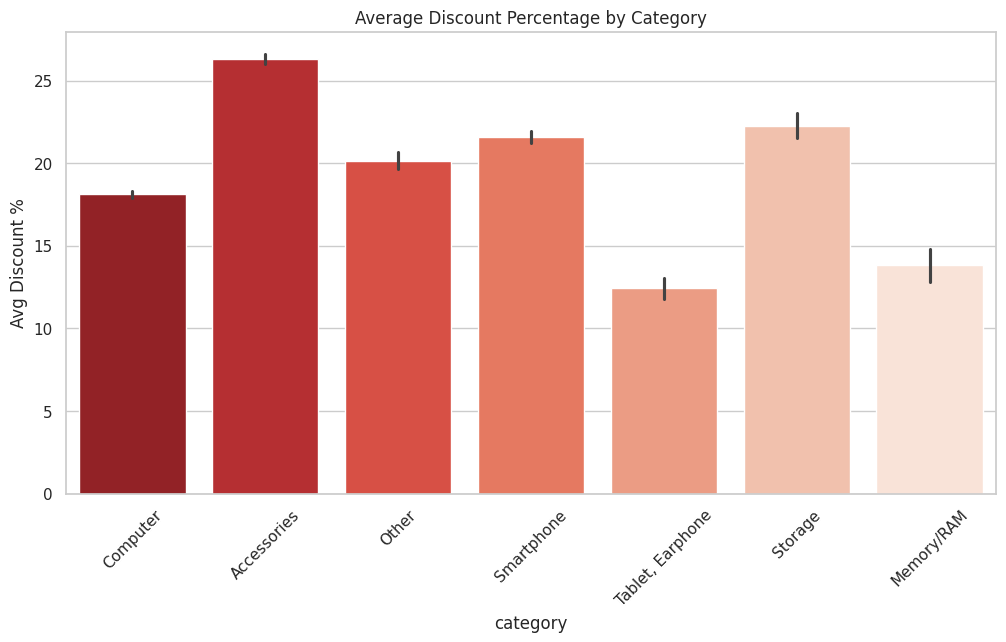

In [53]:
plt.figure(figsize=(12, 6))
# This shows the MEAN discount % for each category
sns.barplot(data=df_cleaned_all, x='category', y='discount_percent', palette='Reds_r')
plt.title('Average Discount Percentage by Category')
plt.ylabel('Avg Discount %')
plt.xticks(rotation=45)
plt.show()

SALES BY CATEGORY OVER THE TIME

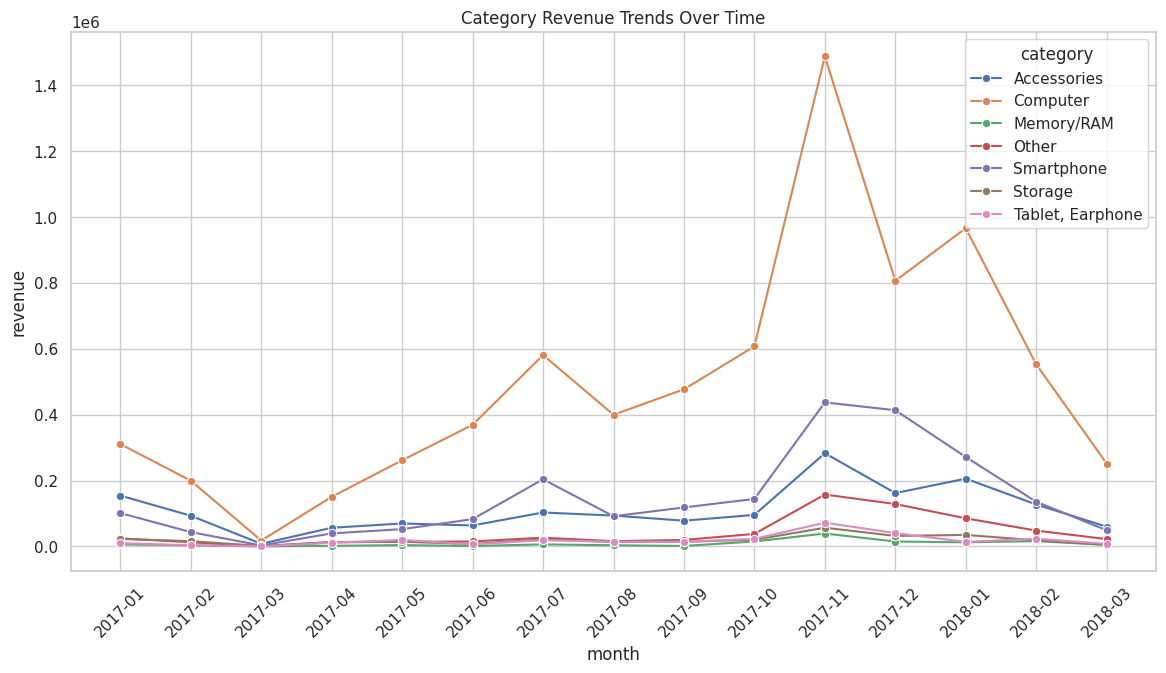

In [54]:
df_cleaned_all['month'] = pd.to_datetime(df_cleaned_all['created_date']).dt.strftime('%Y-%m')
monthly_cat = df_cleaned_all.groupby(['month', 'category'])['revenue'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_cat, x='month', y='revenue', hue='category', marker='o')
plt.title('Category Revenue Trends Over Time')
plt.xticks(rotation=45)
plt.show()

TOP 10 PRODUCTS BY REVENUE ON DISCOUNT

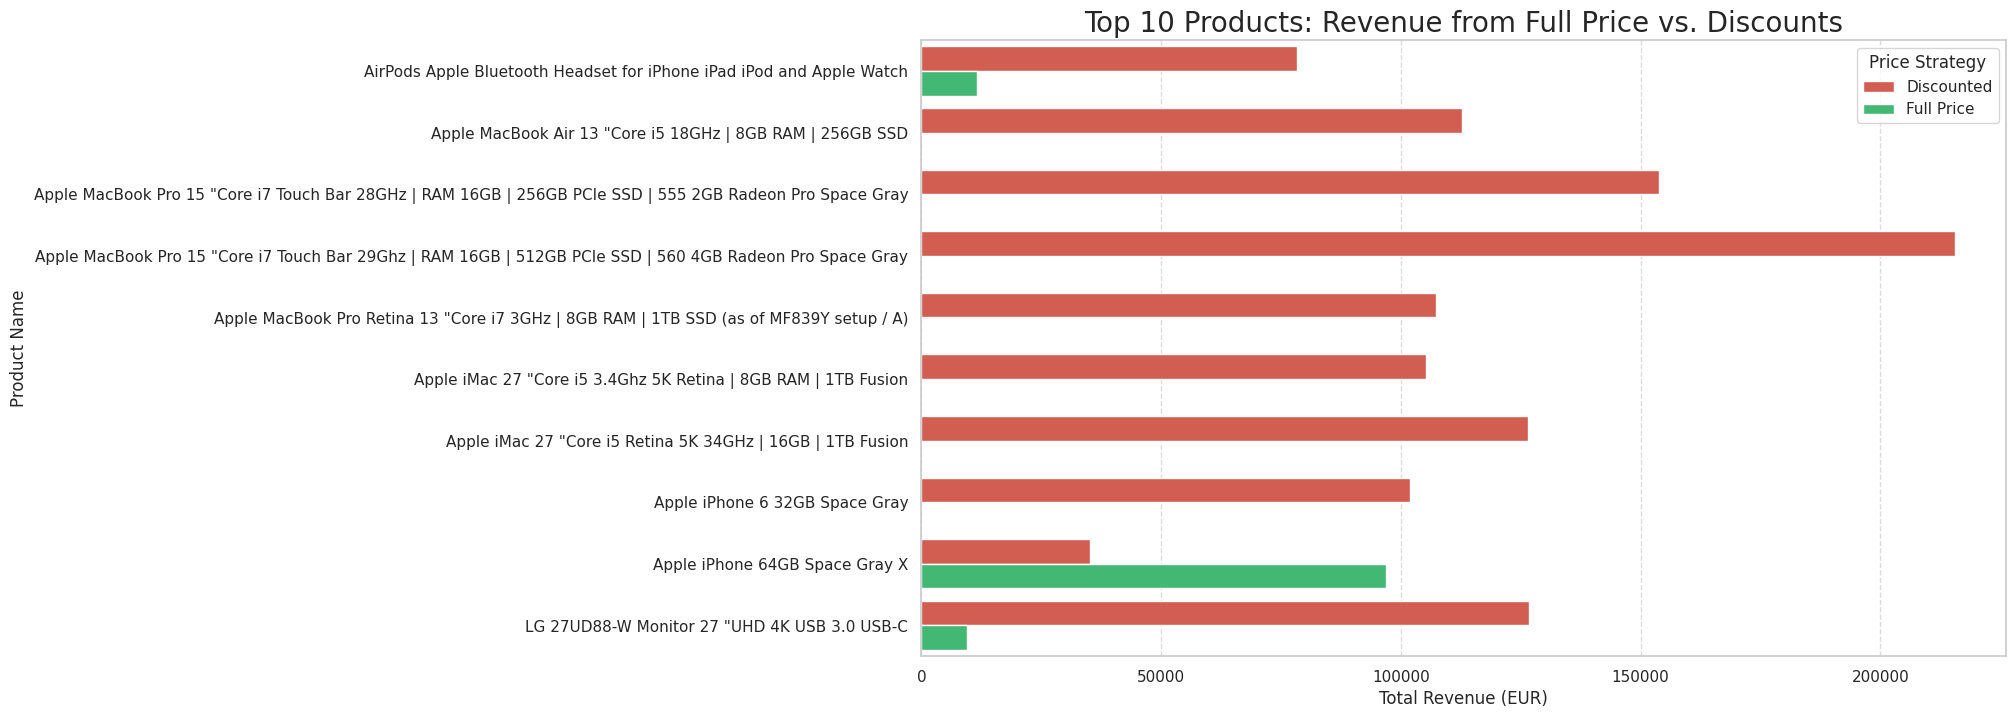

In [55]:

# 1. Identify Top 10 Products by Total Revenue
top_10_names = df_cleaned_all.groupby('name')['revenue'].sum().nlargest(10).index
df_top_10 = df_cleaned_all[df_cleaned_all['name'].isin(top_10_names)].copy()

# 2. Create the "Discount Category" flag
# We'll consider anything with > 2% discount as "Discounted" to ignore rounding errors
df_top_10['price_type'] = df_top_10['discount_percent'].apply(
    lambda x: 'Discounted' if x > 2 else 'Full Price'
)

# 3. Calculate Revenue Split per Product
revenue_split = df_top_10.groupby(['name', 'price_type'])['revenue'].sum().reset_index()

# 4. Plot: Grouped Bar Chart
plt.figure(figsize=(14, 8))
sns.barplot(
    data=revenue_split,
    x='revenue',
    y='name',
    hue='price_type',
    palette={'Full Price': '#2ecc71', 'Discounted': '#e74c3c'} # Green vs Red
)

plt.title('Top 10 Products: Revenue from Full Price vs. Discounts', fontsize=20)
plt.xlabel('Total Revenue (EUR)')
plt.ylabel('Product Name')
plt.legend(title='Price Strategy')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

TOTAL REVENUE VS DISCOUNT % BY CATEGORIES

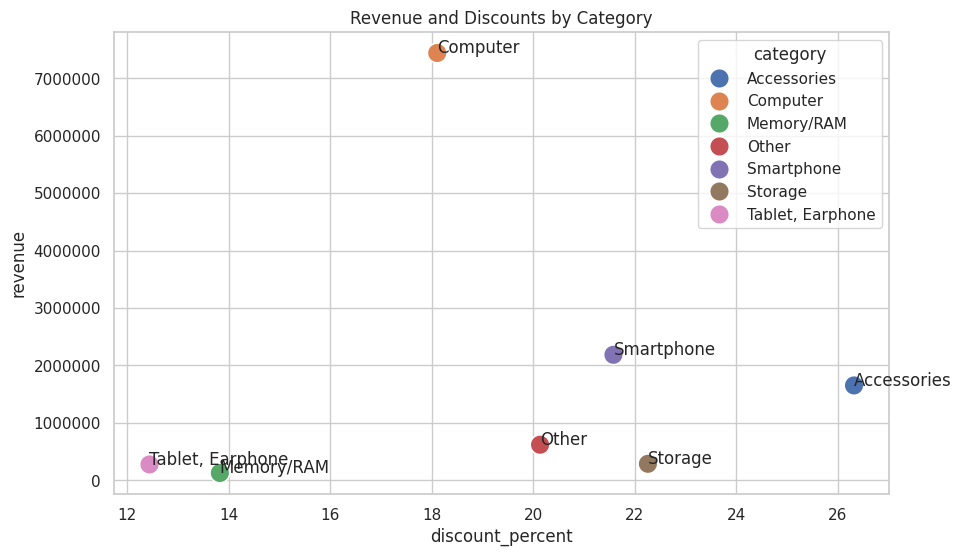

In [56]:
# 1. Simple Grouping
cat_summary = df_cleaned_all.groupby('category').agg({'revenue': 'sum', 'discount_percent': 'mean'}).reset_index()

# 2. Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cat_summary, x='discount_percent', y='revenue', hue='category', s=200)

# 3. THE ERROR-PROOF FIX (Instead of ticklabel_format)
# We just tell the Y-axis: "Show the full number, no scientific notation"
plt.ticklabel_format(style='plain', axis='y')

# 4. Simple Labels
for i in range(len(cat_summary)):
    plt.text(cat_summary.discount_percent[i], cat_summary.revenue[i], cat_summary.category[i])

plt.title('Revenue and Discounts by Category')
plt.show()

BRANDS ON DISCOUNT

In [57]:

# 1. Flag orders as 'Full Price' or 'Discounted'
df_cleaned_all['is_discounted'] = df_cleaned_all['discount_percent'] > 2

# 2. Compare Average Revenue per Order
brand_response = df_cleaned_all.groupby(['short', 'is_discounted']).agg({
    'revenue': 'mean',
    'product_quantity': 'mean'
}).unstack()

# 3. Calculate the "Lift"
# (How much MORE revenue do we get when we discount vs when we don't?)
brand_response['revenue_lift_pct'] = (
    (brand_response[('revenue', True)] / brand_response[('revenue', False)]) - 1
) * 100

print(brand_response.sort_values('revenue_lift_pct', ascending=False))

                  revenue             product_quantity            \
is_discounted       False        True            False      True   
short                                                              
NTE             12.340000   58.932662         1.000000  1.110596   
LOG             22.787667   73.529328         1.233333  1.036176   
ZAG              9.990000   26.039691         1.000000  1.079412   
WAC            103.603148  268.854853         1.231481  1.079976   
PRY             38.835882   97.670000         1.117647  1.030303   
...                   ...         ...              ...       ...   
XDO                   NaN   25.964791              NaN  1.015209   
XOO                   NaN   17.323333              NaN  1.000000   
XRI                   NaN  313.916000              NaN  1.000000   
XTO                   NaN   71.536000              NaN  1.200000   
ZEP                   NaN  115.055000              NaN  1.000000   

              revenue_lift_pct  
is_discounted 

TOP 10 BRANDS ON DISCOUNT SUM

In [58]:
# 1. Group by brand and get the Top 10 by Revenue
top_10_brands = df_cleaned_all.groupby('short').agg({
    'revenue': 'sum',
    'discount_percent': 'mean'
}).sort_values('revenue', ascending=False).head(10).reset_index()

# 2. Rename columns for your slide
top_10_brands.columns = ['Brand', 'Total Revenue', 'Avg Discount %']

print(top_10_brands)

  Brand  Total Revenue  Avg Discount %
0   APP     5249255.97       14.007977
1   PAC     1719257.19       26.733027
2   LAC      513508.47       11.872690
3   OWC      476483.61       22.410194
4   AP2      461366.79       28.182446
5   WAC      458294.76       20.259000
6   LGE      381339.43       10.164965
7   WDT      347732.18       18.833410
8   CRU      284927.18       16.119376
9   DLL      278743.33       17.447867


top 10 brands unit price vs price with full price line

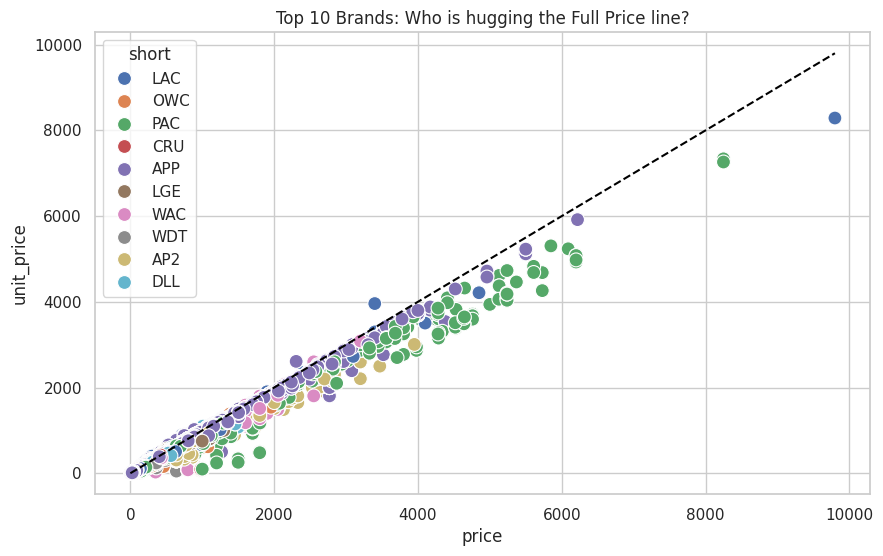

In [59]:
top_10_list = top_10_brands['Brand'].tolist()
df_top_10 = df_cleaned_all[df_cleaned_all['short'].isin(top_10_list)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_top_10, x='price', y='unit_price', hue='short', s=100)

# The "Full Price" Line
max_p = df_top_10['price'].max()
plt.plot([0, max_p], [0, max_p], color='black', linestyle='--')

plt.title('Top 10 Brands: Who is hugging the Full Price line?')
plt.ticklabel_format(style='plain', axis='both')
plt.show()

PIE CHART ON BRANDS

In [60]:

total_rev = df_cleaned_all['revenue'].sum()

# 2. Get Revenue per Brand
brand_rev = df_cleaned_all.groupby('short')['revenue'].sum().reset_index()

# 3. Sort and pick Top 10, group the rest as "Others"
brand_rev = brand_rev.sort_values('revenue', ascending=False)
top_10 = brand_rev.head(10).copy()
others_rev = brand_rev.iloc[10:]['revenue'].sum()

# 4. Add the "Others" row
new_row = pd.DataFrame({'short': ['Others'], 'revenue': [others_rev]})
plot_data = pd.concat([top_10, new_row])

# 5. Calculate Percentage for the labels
plot_data['percent'] = (plot_data['revenue'] / total_rev) * 100

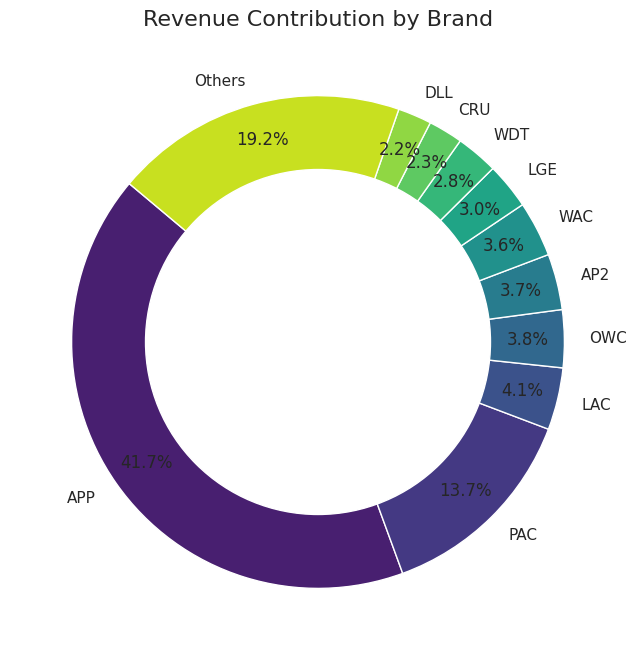

In [61]:
plt.figure(figsize=(8, 8))
plt.pie(plot_data['revenue'], labels=plot_data['short'],
        autopct='%1.1f%%', startangle=140, pctdistance=0.85,
        colors=sns.color_palette('viridis', len(plot_data)))

# Draw a white circle in the middle to make it a "Donut"
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Revenue Contribution by Brand', fontsize=16)
plt.show()

REVENUES BY BRANDS AND CATEGORIS

In [62]:
# 1. Group by Category and Brand to get Total Revenue
cat_brand_rev = df_cleaned_all.groupby(['category', 'long'])['revenue'].sum().reset_index()

# 2. Filter for only the Top 5 of each (to keep it clean for the slide)
top_5_cats = df_cleaned_all.groupby('category')['revenue'].sum().nlargest(5).index
top_5_brands = df_cleaned_all.groupby('long')['revenue'].sum().nlargest(5).index

df_top = cat_brand_rev[
    (cat_brand_rev['category'].isin(top_5_cats)) &
    (cat_brand_rev['long'].isin(top_5_brands))
]

# 3. Create the "Matrix" (The most professional view)
matrix = df_top.pivot(index='category', columns='long', values='revenue').fillna(0)

# Display this in your presentation!
print(matrix)

long              Apple      LaCie        OWC        Pack      Wacom
category                                                            
Accessories   192439.08   13989.97   43486.97    17749.29    3638.25
Computer     3333541.85  499468.51  410847.16  1598525.43  421386.95
Other         237971.84       0.00   12926.70    38569.03   22667.56
Smartphone   1659371.69       0.00       0.00    14343.73    8873.82
Storage        13458.11      49.99    9222.78     5454.43       0.00


CLASSIFICATION OF INCOME BY BRANDS AND CATEGORIES for ppt

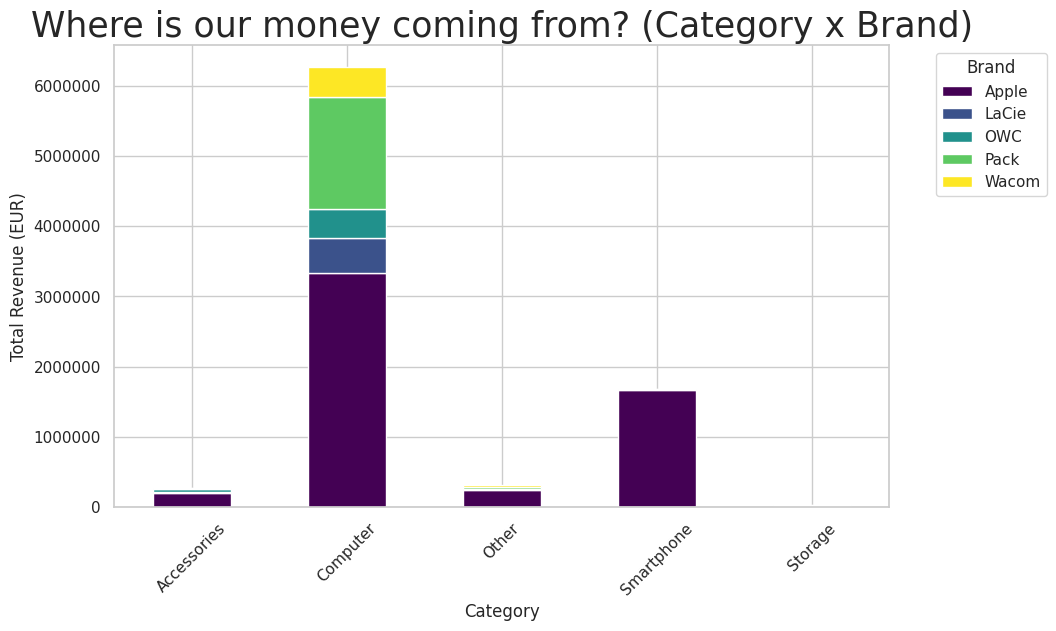

In [63]:
# Plot the Matrix we just made
matrix.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# Add the "Normal Number" fix for the Y-axis
plt.ticklabel_format(style='plain', axis='y')

plt.title('Where is our money coming from? (Category x Brand)', fontsize=25)
plt.ylabel('Total Revenue (EUR)')
plt.xlabel('Category')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

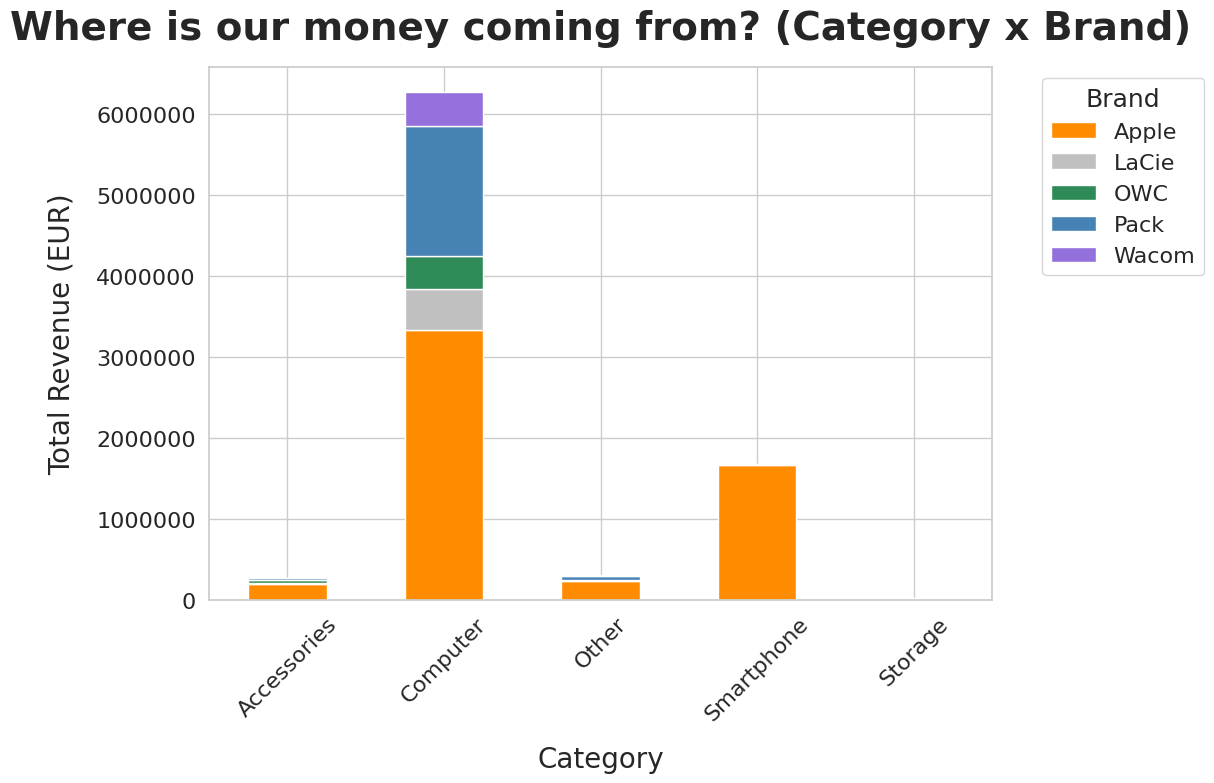

In [64]:
focus_colors = ['#FF8C00', '#C0C0C0', '#2E8B57', '#4682B4', '#9370DB']

ax = matrix.plot(kind='bar', stacked=True, figsize=(12, 8), color=focus_colors)
# 2. Fix the Y-axis numbers to be normal (not scientific notation)
plt.ticklabel_format(style='plain', axis='y')

# 3. INCREASE ALL FONT SIZES
plt.title('Where is our money coming from? (Category x Brand)', fontsize=28, fontweight='bold', pad=20)
plt.ylabel('Total Revenue (EUR)', fontsize=20, labelpad=15)
plt.xlabel('Category', fontsize=20, labelpad=15)

# 4. Make the Category names and Revenue numbers bigger
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

# 5. Make the Legend readable
plt.legend(title='Brand', title_fontsize=18, fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



Discount Effectiveness: by category for ppt

/tmp/ipykernel_14148/396404900.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_efficiency = df_plot.groupby(['discount_bucket', 'category'])['revenue'].mean().reset_index()


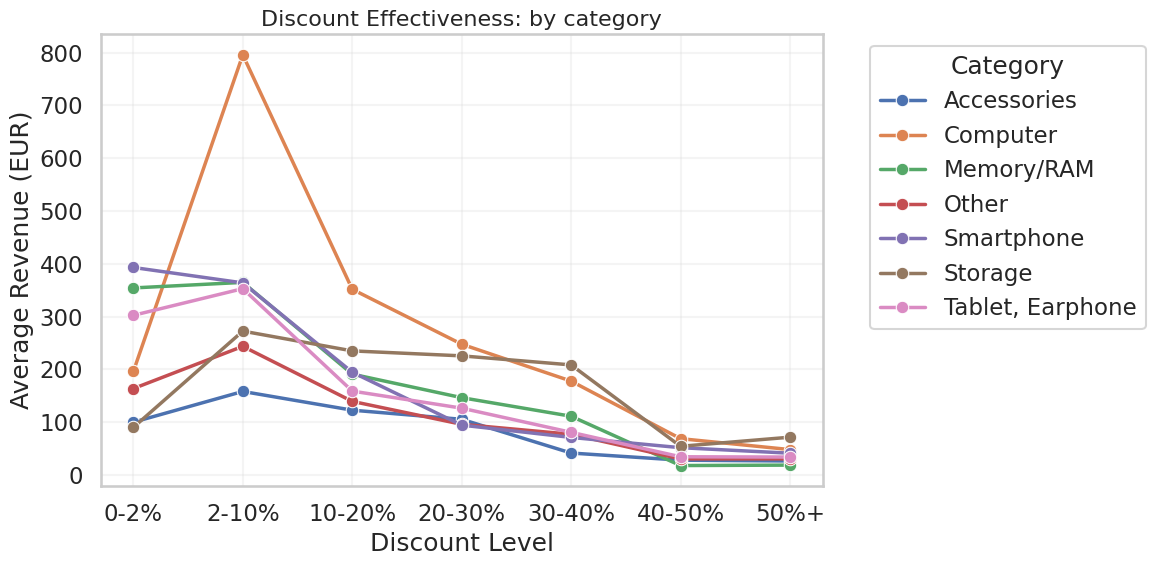

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_context("talk") # Options: "paper", "notebook", "talk", "poster"

# 1. Create 10% Discount Buckets (0-10%, 10-20%, etc.)
bins = [-1, 2, 10, 20, 30, 40, 50, 100]
labels = ['0-2%', '2-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
df_cleaned_all['discount_bucket'] = pd.cut(df_cleaned_all['discount_percent'], bins=bins, labels=labels)

# 2. Get the Top 10 Categories by Revenue
top_10_cats = df_cleaned_all.groupby('category')['revenue'].sum().nlargest(10).index
df_plot = df_cleaned_all[df_cleaned_all['category'].isin(top_10_cats)]

# 3. Calculate Average Revenue per Category per Bucket
cat_efficiency = df_plot.groupby(['discount_bucket', 'category'])['revenue'].mean().reset_index()

# 4. Plot the "Effectiveness" Lines
plt.figure(figsize=(12, 6))
sns.lineplot(data=cat_efficiency, x='discount_bucket', y='revenue', hue='category', marker='o', linewidth=2.5)

# Normal numbers for Y-axis
plt.ticklabel_format(style='plain', axis='y')

plt.title('Discount Effectiveness: by category', fontsize=16)
plt.ylabel('Average Revenue (EUR)')
plt.xlabel('Discount Level')
plt.grid(True, alpha=0.2)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14148/2359259666.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_efficiency = df_plot.groupby(['discount_bucket', 'category'])['revenue'].mean().reset_index()


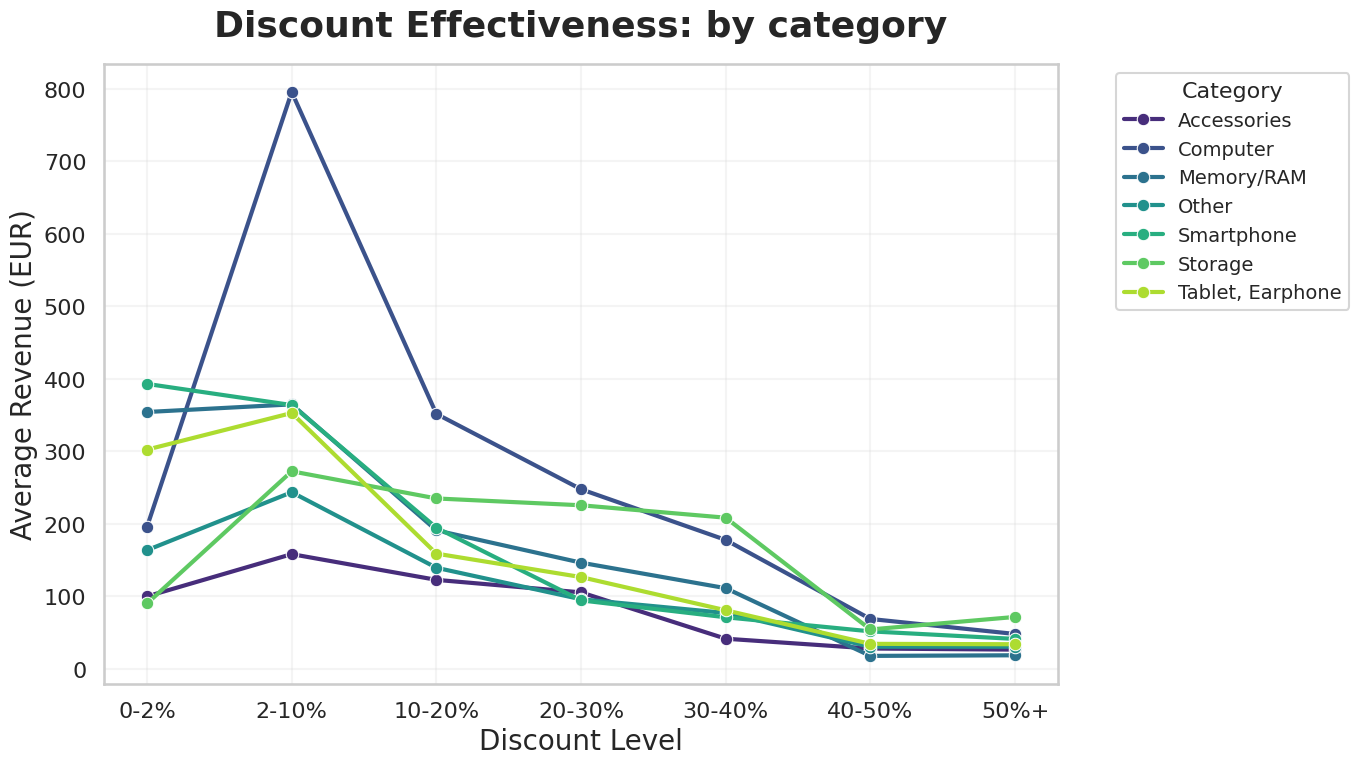

In [66]:
# 0. Set the context for high-impact PPT fonts
sns.set_context("talk")

# 1. Create 10% Discount Buckets (0-10%, 10-20%, etc.)
bins = [-1, 2, 10, 20, 30, 40, 50, 100]
labels = ['0-2%', '2-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
df_cleaned_all['discount_bucket'] = pd.cut(df_cleaned_all['discount_percent'], bins=bins, labels=labels)

# 2. Get the Top 10 Categories
top_10_cats = df_cleaned_all.groupby('category')['revenue'].sum().nlargest(10).index
df_plot = df_cleaned_all[df_cleaned_all['category'].isin(top_10_cats)]

# 3. Calculate Average Revenue
cat_efficiency = df_plot.groupby(['discount_bucket', 'category'])['revenue'].mean().reset_index()

# 4. Plot with VIRIDIS Palette
plt.figure(figsize=(14, 8))
# 'palette' is the keyword for Seaborn colors
sns.lineplot(
    data=cat_efficiency,
    x='discount_bucket',
    y='revenue',
    hue='category',
    marker='o',
    linewidth=3,
    palette='viridis'
)

# 5. Fix Scientific Notation and Increase Font Sizes for PPT
plt.ticklabel_format(style='plain', axis='y')

plt.title('Discount Effectiveness: by category', fontsize=26, fontweight='bold', pad=20)
plt.ylabel('Average Revenue (EUR)', fontsize=20)
plt.xlabel('Discount Level', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# 6. Clean up Legend
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

 Revenue Share % by categories

In [67]:

# 1. Calculate Revenue Share
cat_rev = df_cleaned_all.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
total_revenue = cat_rev['revenue'].sum()
cat_rev['percent'] = (cat_rev['revenue'] / total_revenue) * 100

# 2. Group minor categories into "Others" for a clean slide
top_5 = cat_rev.head(5).copy()
others_val = cat_rev.iloc[5:]['revenue'].sum()
others_pct = cat_rev.iloc[5:]['percent'].sum()

# Add "Others" row
top_5.loc[len(top_5)] = ['Others', others_val, others_pct]

print("--- Revenue Share by Category ---")
print(top_5[['category', 'percent']])

--- Revenue Share by Category ---
      category    percent
0     Computer  59.084490
1   Smartphone  17.360328
2  Accessories  13.122024
3        Other   4.925765
4      Storage   2.289509
5       Others   3.217884


PIE CHART ON REVENUE %

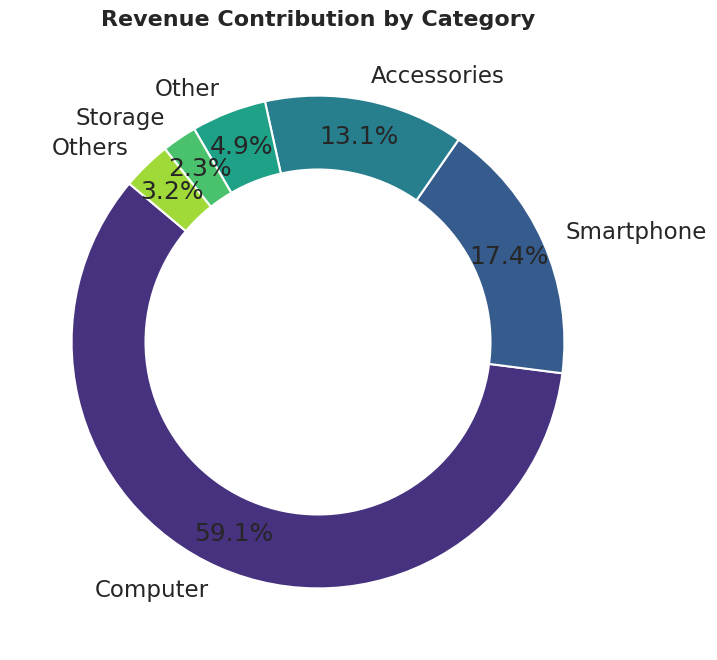

In [68]:

# 1. Calculate Revenue Share
cat_rev = df_cleaned_all.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
total_rev = cat_rev['revenue'].sum()
cat_rev['percent'] = (cat_rev['revenue'] / total_rev) * 100

# 2. Simplify for Slide: Keep Top 5 and group the rest as "Others"
top_5 = cat_rev.head(5).copy()
if len(cat_rev) > 5:
    others_rev = cat_rev.iloc[5:]['revenue'].sum()
    others_pct = cat_rev.iloc[5:]['percent'].sum()
    top_5.loc[len(top_5)] = ['Others', others_rev, others_pct]

# 3. Create the Visualization
plt.figure(figsize=(8, 8))
plt.pie(top_5['revenue'], labels=top_5['category'], autopct='%1.1f%%',
        startangle=140, pctdistance=0.85, colors=sns.color_palette('viridis'))

# Draw center circle to make it a "Donut" (more modern for PPT)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.title('Revenue Contribution by Category', fontsize=16, fontweight='bold')
plt.show()

BONUS ADVANCED

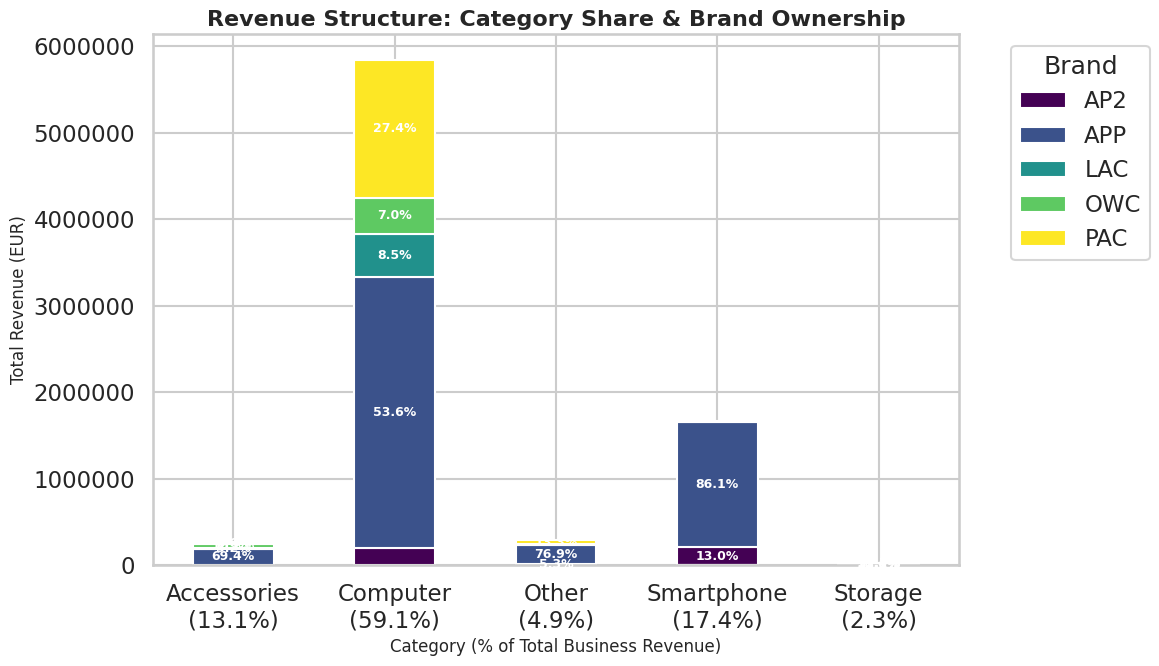

In [69]:
def plot_advanced_stacked_bar(df):
    # 1. Calculate Total Company Revenue for the global percentages
    total_company_revenue = df['revenue'].sum()

    # 2. Pick Top 5 Categories & Top 5 Brands for a clean slide
    top_cats = df.groupby('category')['revenue'].sum().nlargest(5).index
    top_brands = df.groupby('short')['revenue'].sum().nlargest(5).index

    # 3. Build the Matrix
    df_filtered = df[df['category'].isin(top_cats) & df['short'].isin(top_brands)]
    matrix = df_filtered.groupby(['category', 'short'])['revenue'].sum().unstack().fillna(0)

    # 4. Calculate Category % of TOTAL Business Revenue
    cat_totals = df.groupby('category')['revenue'].sum()
    cat_percents = (cat_totals / total_company_revenue) * 100

    # 5. Create new X-axis labels: e.g., "Smartphones (55.4%)"
    new_labels = [f"{cat}\n({cat_percents[cat]:.1f}%)" for cat in matrix.index]

    # 6. Plotting the Stacked Bars (Total EUR)
    ax = matrix.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

    # 7. ADD % LABELS INSIDE THE BARS (Brand Share per Category)
    for i, (idx, row) in enumerate(matrix.iterrows()):
        cumulative_height = 0
        cat_sum = row.sum() # Total revenue for JUST this category
        for brand in matrix.columns:
            val = row[brand]
            if val > 0:
                # Calculate the % this brand represents within this specific category
                brand_pct = (val / cat_sum) * 100

                # Only show label if the bar segment is large enough to read
                if brand_pct > 5:
                    ax.text(i, cumulative_height + val/2, f'{brand_pct:.1f}%',
                            ha='center', va='center', color='white',
                            fontweight='bold', fontsize=9)
            cumulative_height += val

    # 8. Formatting for the Board
    plt.title('Revenue Structure: Category Share & Brand Ownership', fontsize=16, fontweight='bold')
    plt.ylabel('Total Revenue (EUR)', fontsize=12)
    plt.xlabel('Category (% of Total Business Revenue)', fontsize=12)
    plt.xticks(range(len(new_labels)), new_labels, rotation=0)
    plt.ticklabel_format(style='plain', axis='y')
    plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the function on your dataframe
plot_advanced_stacked_bar(df_cleaned_all)

FOR PPT: % REVENUE BY CATEGORY

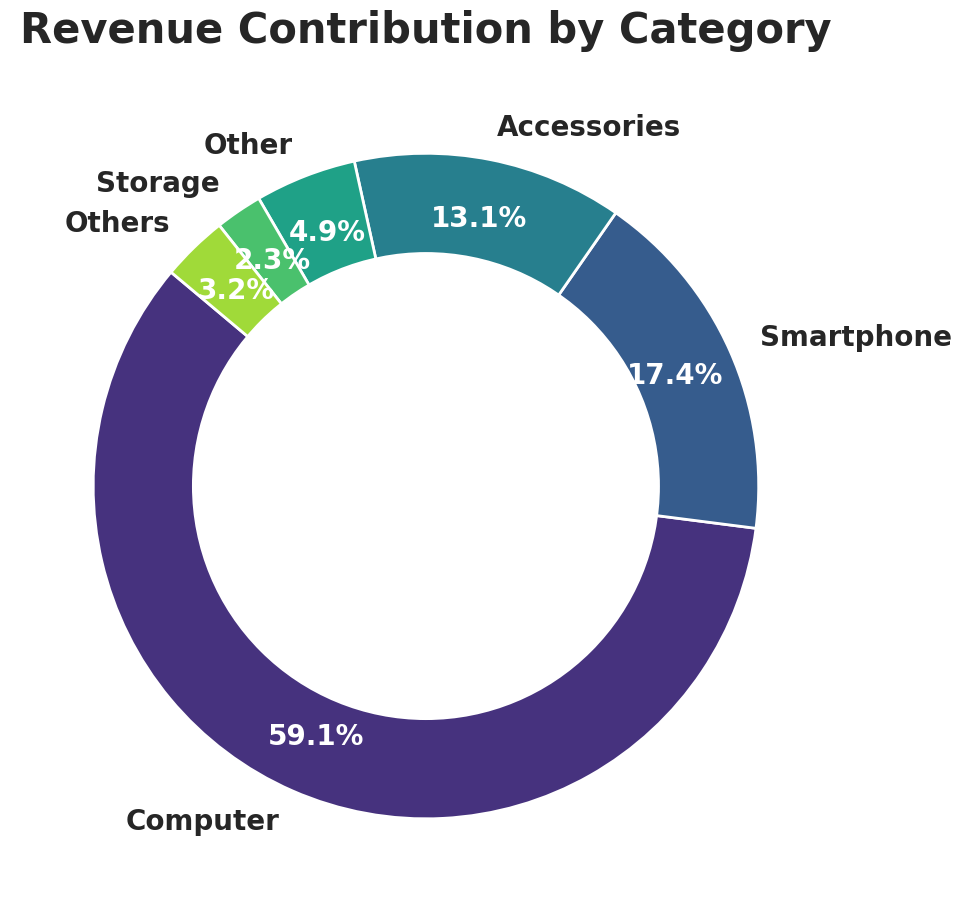

In [70]:
# 1. Grouping Logic (Same as your original)
cat_rev = df_cleaned_all.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
total_rev = cat_rev['revenue'].sum()
cat_rev['percent'] = (cat_rev['revenue'] / total_rev) * 100

top_5 = cat_rev.head(5).copy()
if len(cat_rev) > 5:
    others_rev = cat_rev.iloc[5:]['revenue'].sum()
    others_pct = (others_rev / total_rev) * 100
    # Use pd.concat for cleaner appending
    others_df = pd.DataFrame({'category': ['Others'], 'revenue': [others_rev], 'percent': [others_pct]})
    top_5 = pd.concat([top_5, others_df], ignore_index=True)

# 2. Create the Visualization with High Contrast
plt.figure(figsize=(10, 10))

# Store the text objects (patches, texts, autotexts) to modify them
patches, texts, autotexts = plt.pie(
    top_5['revenue'],
    labels=top_5['category'],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,          # Moves percentages slightly toward the edge
    labeldistance=1.1,         # Moves category names further out
    colors=sns.color_palette('viridis'),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Adds a small border between slices
)

# 3. FIX THE FONT: Make percentages Bold, White, and Large
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(20)

# 4. Make Category Labels (outside) easier to read
for text in texts:
    text.set_fontsize(20)
    text.set_weight('semibold')

# Draw center circle
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.title('Revenue Contribution by Category', fontsize=30, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

FOR PPT:  Where is our money coming from? (Category x Brand)

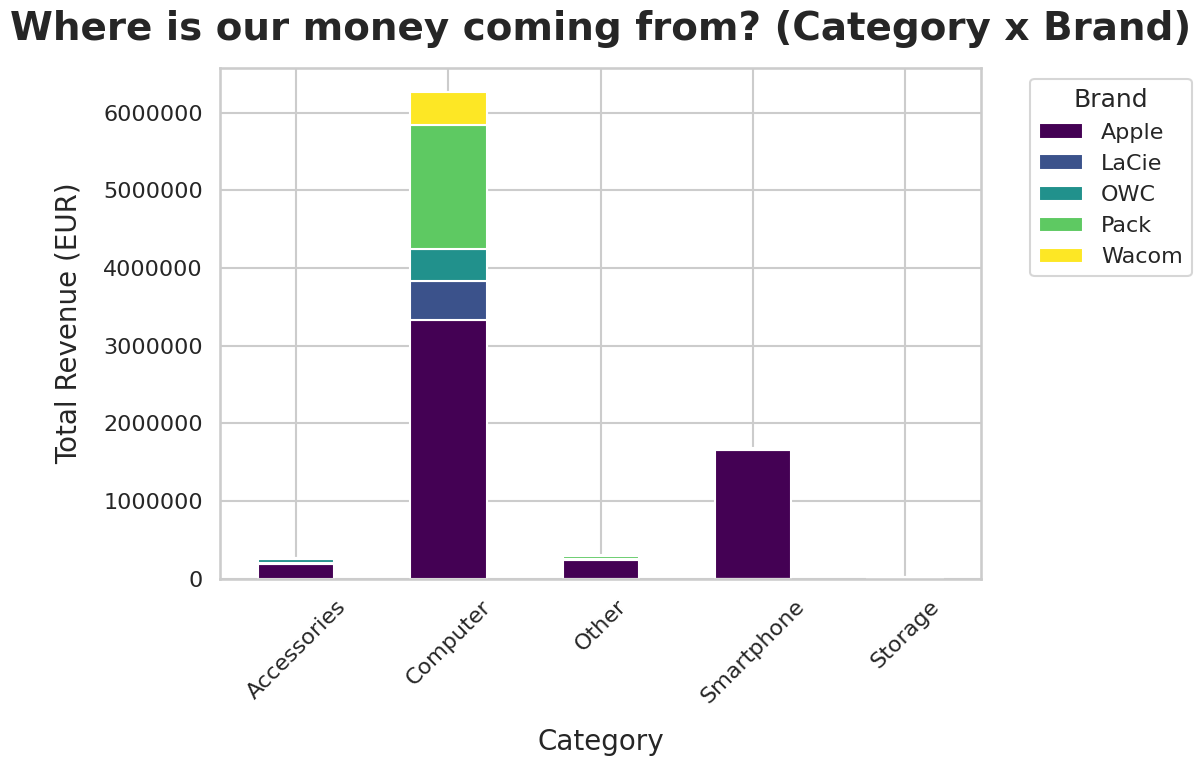

In [71]:


# 1. Create the plot
ax = matrix.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

# 2. Fix the Y-axis numbers to be normal (not scientific notation)
plt.ticklabel_format(style='plain', axis='y')

# 3. INCREASE ALL FONT SIZES
plt.title('Where is our money coming from? (Category x Brand)', fontsize=28, fontweight='bold', pad=20)
plt.ylabel('Total Revenue (EUR)', fontsize=20, labelpad=15)
plt.xlabel('Category', fontsize=20, labelpad=15)

# 4. Make the Category names and Revenue numbers bigger
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

# 5. Make the Legend readable
plt.legend(title='Brand', title_fontsize=18, fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

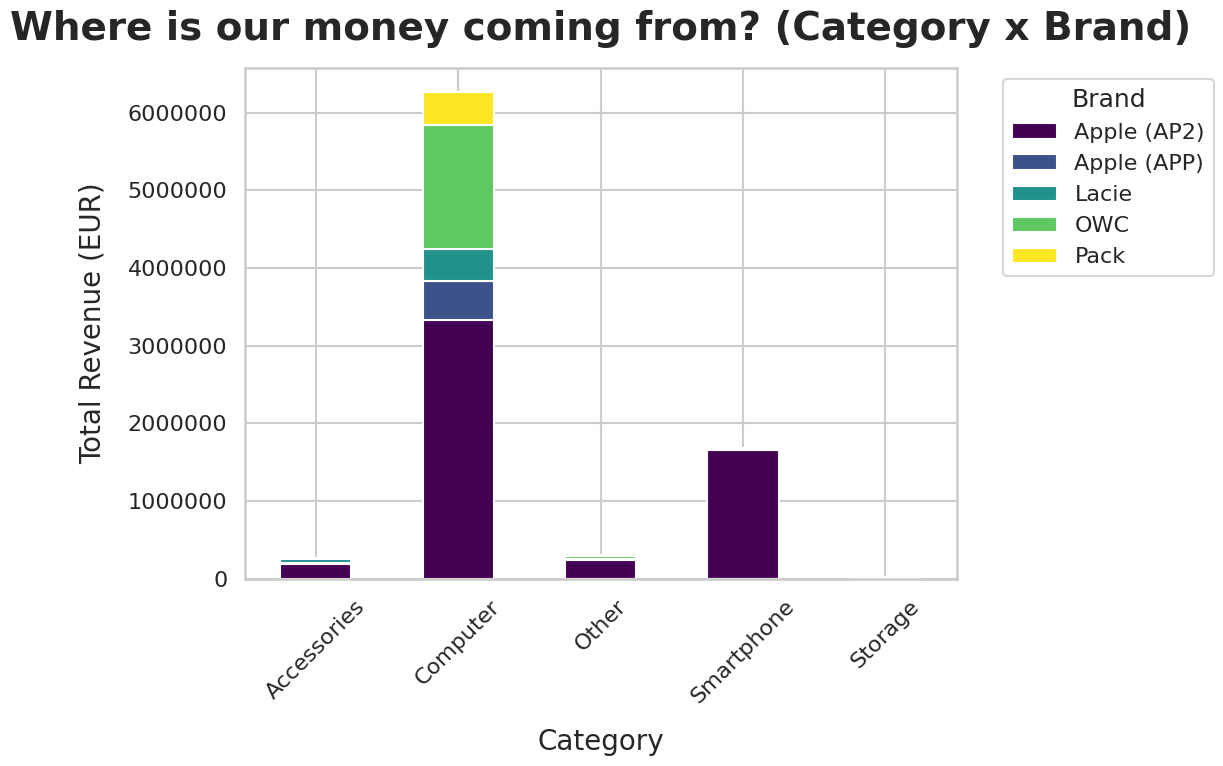

In [72]:
# 1. Create the plot
ax = matrix.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

# 2. Fix the Y-axis numbers
plt.ticklabel_format(style='plain', axis='y')

# 3. INCREASE ALL FONT SIZES
plt.title('Where is our money coming from? (Category x Brand)', fontsize=28, fontweight='bold', pad=20)
plt.ylabel('Total Revenue (EUR)', fontsize=20, labelpad=15)
plt.xlabel('Category', fontsize=20, labelpad=15)

# 4. Make the Category names and Revenue numbers bigger
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

# 5. Make the Legend readable with CUSTOM LABELS
# We pass the new names in the 'labels' argument
new_labels = ['Apple (AP2)', 'Apple (APP)', 'Lacie', 'OWC', 'Pack']

plt.legend(
    labels=new_labels,
    title='Brand',
    title_fontsize=18,
    fontsize=16,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()